<a href="https://colab.research.google.com/github/1816x/Algoritmos-Aprendizaje-Automatico/blob/main/Avance_Proyecto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avance de Proyecto - Telco Customer Churn

## Predicción de abandono de clientes

Este notebook construye una línea base reproducible para un problema de clasificación binaria.

Dataset utilizado:
Telco Customer Churn - BlastChar (Kaggle)

Variable objetivo:
- Churn = 1 → cliente abandona
- Churn = 0 → cliente permanece

Carga diseñada para Google Colab usando URL directa del archivo, sin instalar librerías adicionales.

In [3]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import sklearn
import sys

print("python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


## Carga del dataset

El dataset se carga directamente desde GitHub para evitar descargas manuales o instalaciones adicionales.

Si la liga cambia, únicamente se modifica esta celda.

In [4]:
# upload kaggle dataset manually from colab

from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

Saving archive.zip to archive.zip


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# initial exploration

print("shape:", df.shape)

display(df.head())
display(df.tail())

df.info()

display(df.describe(include="all").T)

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# missing values and duplicates

missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percentage": df.isna().mean()*100
})

display(missing)

print("duplicates:", df.duplicated().sum())

,missing,percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


duplicates: 0


In [7]:
# unique values

for column in df.columns:
    print(column, ":", df[column].nunique())

customerID : 7043
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


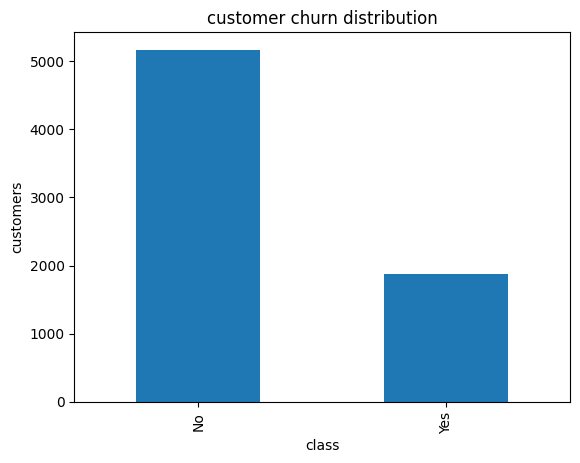

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [8]:
# target distribution

df["Churn"].value_counts().plot(kind="bar")

plt.title("customer churn distribution")
plt.xlabel("class")
plt.ylabel("customers")

plt.show()

print(df["Churn"].value_counts(normalize=True))

## Limpieza de datos

Se eliminan identificadores únicos y se convierte TotalCharges porque viene almacenada como texto.

In [9]:
# convert total charges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# remove identifier

df = df.drop(columns=["customerID"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
# encode target

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(X.shape)
print(y.value_counts())

(7043, 19)
Churn
0    5174
1    1869
Name: count, dtype: int64


## División de datos

Se utiliza:

- 70% entrenamiento
- 15% validación
- 15% prueba

Con estratificación para conservar la proporción de abandono.

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4930, 19)
(1056, 19)
(1057, 19)


In [12]:
# preprocessing pipeline

numeric_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## Modelos iniciales

Comparación:

1. DummyClassifier → baseline
2. Logistic Regression
3. Decision Tree

In [13]:
models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "decision tree": DecisionTreeClassifier(
        random_state=42
    )
}


results = {}

pipelines = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    prediction = pipe.predict(X_val)
    probability = pipe.predict_proba(X_val)[:,1]

    pipelines[name] = pipe

    results[name] = {
        "accuracy": accuracy_score(y_val,prediction),
        "precision": precision_score(y_val,prediction),
        "recall": recall_score(y_val,prediction),
        "f1": f1_score(y_val,prediction),
        "roc_auc": roc_auc_score(y_val,probability)
    }


results_df = pd.DataFrame(results).T

results_df

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,accuracy,precision,recall,f1,roc_auc
dummy,0.734848,0.000000,0.000000,0.000000,0.500000
logistic regression,0.805871,0.645914,0.592857,0.618250,0.845312
decision tree,0.716856,0.467128,0.482143,0.474517,0.641177


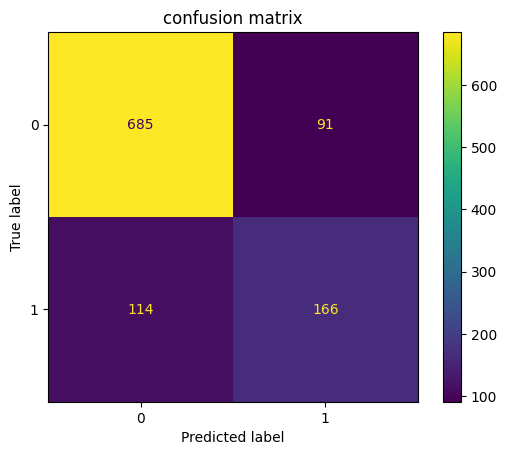

[[685  91]
 [114 166]]


In [14]:
# select logistic regression

model = pipelines["logistic regression"]

prediction = model.predict(X_val)
probability = model.predict_proba(X_val)[:,1]


ConfusionMatrixDisplay.from_predictions(
    y_val,
    prediction
)

plt.title("confusion matrix")
plt.show()


print(confusion_matrix(y_val,prediction))

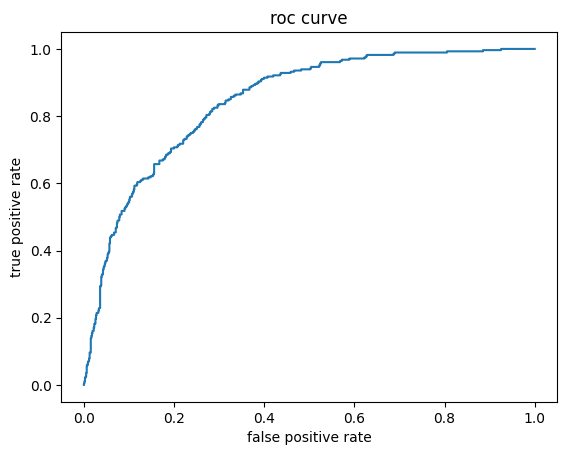

roc auc: 0.8453124999999999


In [15]:
# roc curve

fpr, tpr, thresholds = roc_curve(
    y_val,
    probability
)

plt.plot(fpr,tpr)

plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc curve")

plt.show()

print(
    "roc auc:",
    roc_auc_score(y_val,probability)
)

In [16]:
# threshold analysis

for threshold in [0.5,0.4,0.3]:

    pred = (probability >= threshold).astype(int)

    print("threshold:", threshold)
    print("precision:", precision_score(y_val,pred))
    print("recall:", recall_score(y_val,pred))
    print("f1:", f1_score(y_val,pred))
    print("----------------")

threshold: 0.5
precision: 0.6459143968871596
recall: 0.5928571428571429
f1: 0.6182495344506518
----------------
threshold: 0.4
precision: 0.5609065155807366
recall: 0.7071428571428572
f1: 0.6255924170616114
----------------
threshold: 0.3
precision: 0.5187793427230047
recall: 0.7892857142857143
f1: 0.6260623229461756
----------------


## Análisis final

El modelo seleccionado preliminarmente será Logistic Regression debido a:

- buena interpretabilidad
- desempeño superior al baseline
- menor complejidad
- facilidad para explicar decisiones

 Su función es apoyar acciones de retención.

